In [1]:
# STEP 1: Environment Setup & Verification
# =========================================

# --- 1. Install/Import required libraries ---
# On Kaggle, gymnasium is usually not pre-installed, so we install it first.
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import torch
import random

# --- 2. Set random seeds for reproducibility ---
# This ensures that random numbers (used later for exploration, weight init, etc.)
# are reproducible across runs. Reproducibility is CRITICAL for this project,
# since we will compare optimizers across multiple seeds.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If a GPU is available, also seed CUDA operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# --- 3. Detect CPU/GPU ---
# We will use GPU if available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 4. Create the CartPole-v1 environment ---
# CartPole-v1 is a classic control environment where the agent must
# balance a pole on a moving cart by pushing it left or right.
env = gym.make("CartPole-v1")

# --- 5. Display the observation space ---
# The observation space describes what information the agent receives
# at each step: [cart position, cart velocity, pole angle, pole angular velocity]
print("\nObservation space:", env.observation_space)
print("Observation space shape:", env.observation_space.shape)
print("Observation space low bounds:", env.observation_space.low)
print("Observation space high bounds:", env.observation_space.high)

# --- 6. Display the action space ---
# The action space describes what actions the agent can take.
# For CartPole: 0 = push cart left, 1 = push cart right
print("\nAction space:", env.action_space)
print("Number of possible actions:", env.action_space.n)

# --- 7. Run a few random actions to verify the environment works ---
# We reset the environment, then take random actions for a few steps,
# just to confirm that the environment responds correctly (no crashes,
# reasonable output shapes, etc.)
observation, info = env.reset(seed=SEED)
print("\nInitial observation:", observation)

print("\nRunning 5 random steps...")
for step in range(5):
    action = env.action_space.sample()  # pick a random action (0 or 1)
    observation, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step+1}: action={action}, observation={observation}, "
          f"reward={reward}, terminated={terminated}, truncated={truncated}")

    if terminated or truncated:
        print("Episode ended early, resetting environment...")
        observation, info = env.reset()

env.close()
print("\nEnvironment test completed successfully.")

Using device: cuda

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation space shape: (4,)
Observation space low bounds: [-4.8               -inf -0.41887903        -inf]
Observation space high bounds: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
Number of possible actions: 2

Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Running 5 random steps...
Step 1: action=1, observation=[ 0.02727336  0.18847767  0.03625453 -0.26141977], reward=1.0, terminated=False, truncated=False
Step 2: action=0, observation=[ 0.03104291 -0.00714255  0.03102613  0.04247424], reward=1.0, terminated=False, truncated=False
Step 3: action=0, observation=[ 0.03090006 -0.20269535  0.03187562  0.3447825 ], reward=1.0, terminated=False, truncated=False
Step 4: action=1, observation=[ 0.02684616 -0.008041    0.03877127  0.06231914], reward=1.0, terminated=False, truncated

In [2]:
# STEP 2: Deep Q-Network (DQN) Architecture
# =========================================

import torch
import torch.nn as nn

# --- 1. Define the DQN class ---
class DQN(nn.Module):
    """
    A simple feedforward neural network that approximates Q(s, a).

    Architecture:
        Input layer:   4 neurons  (state: cart position, cart velocity,
                                    pole angle, pole angular velocity)
        Hidden layer 1: 128 neurons + ReLU
        Hidden layer 2: 128 neurons + ReLU
        Output layer:   2 neurons (Q-value for action 0, Q-value for action 1)
    """

    def __init__(self, input_size=4, hidden_size=128, output_size=2):
        super(DQN, self).__init__()

        # First fully connected layer: takes the 4 state values
        # and projects them into a 128-dimensional hidden representation.
        self.fc1 = nn.Linear(input_size, hidden_size)

        # Second fully connected layer: transforms the 128-dim
        # representation into another 128-dim representation,
        # allowing the network to learn more complex patterns.
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        # Output layer: maps the 128-dim representation to 2 values,
        # one Q-value per possible action (left, right).
        self.out = nn.Linear(hidden_size, output_size)

        # ReLU activation introduces non-linearity between layers,
        # allowing the network to learn more than just linear relationships.
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass input through first layer + activation
        x = self.relu(self.fc1(x))

        # Pass through second layer + activation
        x = self.relu(self.fc2(x))

        # Output layer: no activation here, because Q-values
        # can be any real number (positive or negative), not bounded like a probability.
        q_values = self.out(x)

        return q_values


# --- 2. Instantiate the model ---
model = DQN(input_size=4, hidden_size=128, output_size=2)
model = model.to(device)  # move model to GPU if available

# --- 3. Print the model architecture ---
print("DQN Architecture:")
print(model)

# --- 4. Perform one forward pass using a sample observation ---
# We reuse the environment from Step 1 to get a real observation.
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=SEED)

# Convert the observation (numpy array) into a PyTorch tensor.
# We add a batch dimension with unsqueeze(0), since the network
# expects input shape [batch_size, 4], not just [4].
state_tensor = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

print("\nSample observation:", observation)
print("Observation as tensor:", state_tensor)

# Forward pass: no training, just inference.
# torch.no_grad() disables gradient tracking since we are not training yet.
with torch.no_grad():
    q_values = model(state_tensor)

# --- 5. Print the predicted Q-values ---
print("\nPredicted Q-values:", q_values)

env.close()

DQN Architecture:
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)

Sample observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation as tensor: tensor([[ 0.0274, -0.0061,  0.0359,  0.0197]], device='cuda:0')

Predicted Q-values: tensor([[ 0.0207, -0.0128]], device='cuda:0')


In [3]:
# STEP 3: Replay Buffer
# =========================================

from collections import deque
import random

class ReplayBuffer:
    """
    A simple experience replay buffer for DQN.

    Stores transitions (state, action, reward, next_state, done)
    and allows random sampling of minibatches for training.
    """

    def __init__(self, capacity):
        # deque with a maximum length automatically discards the oldest
        # transition once the buffer is full, keeping memory usage bounded.
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        """
        Store one transition in the buffer.

        Parameters:
            state (np.array): current state
            action (int): action taken (0 or 1)
            reward (float): reward received
            next_state (np.array): resulting state
            done (bool): whether the episode ended after this transition
        """
        transition = (state, action, reward, next_state, done)
        self.buffer.append(transition)

    def sample(self, batch_size):
        """
        Randomly sample a minibatch of transitions from the buffer.

        Parameters:
            batch_size (int): number of transitions to sample

        Returns:
            A tuple of 5 lists: states, actions, rewards, next_states, dones
        """
        # random.sample() picks 'batch_size' unique random transitions,
        # ensuring no duplicates within the same batch and breaking
        # any temporal correlation.
        batch = random.sample(self.buffer, batch_size)

        # Unpack the batch of tuples into 5 separate lists
        # (one list per element of the transition).
        states, actions, rewards, next_states, dones = zip(*batch)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        """
        Returns the current number of transitions stored in the buffer.
        Useful to check if the buffer has enough data before sampling.
        """
        return len(self.buffer)


# --- Example usage ---

# 1. Initialize the buffer with a maximum capacity of 1000 transitions
buffer = ReplayBuffer(capacity=1000)

# 2. Insert a few fake transitions (simulating CartPole-like data)
buffer.add(state=[0.01, 0.02, 0.03, 0.04], action=0, reward=1.0,
           next_state=[0.02, 0.03, 0.04, 0.05], done=False)

buffer.add(state=[0.02, 0.03, 0.04, 0.05], action=1, reward=1.0,
           next_state=[0.03, 0.04, 0.05, 0.06], done=False)

buffer.add(state=[0.03, 0.04, 0.05, 0.06], action=0, reward=1.0,
           next_state=[0.04, 0.05, 0.06, 0.07], done=False)

buffer.add(state=[0.04, 0.05, 0.06, 0.07], action=1, reward=0.0,
           next_state=[0.05, 0.06, 0.07, 0.08], done=True)

buffer.add(state=[0.05, 0.06, 0.07, 0.08], action=0, reward=1.0,
           next_state=[0.06, 0.07, 0.08, 0.09], done=False)

print(f"Number of transitions stored: {len(buffer)}")

# 3. Sample a minibatch of size 3
states, actions, rewards, next_states, dones = buffer.sample(batch_size=3)

# 4. Print the sampled data
print("\nSampled states:     ", states)
print("Sampled actions:    ", actions)
print("Sampled rewards:    ", rewards)
print("Sampled next_states:", next_states)
print("Sampled dones:      ", dones)

Number of transitions stored: 5

Sampled states:      ([0.01, 0.02, 0.03, 0.04], [0.05, 0.06, 0.07, 0.08], [0.03, 0.04, 0.05, 0.06])
Sampled actions:     (0, 0, 0)
Sampled rewards:     (1.0, 1.0, 1.0)
Sampled next_states: ([0.02, 0.03, 0.04, 0.05], [0.06, 0.07, 0.08, 0.09], [0.04, 0.05, 0.06, 0.07])
Sampled dones:       (False, False, False)


In [4]:
# STEP 4: DQN Agent
# =========================================

import torch
import numpy as np

class DQNAgent:
    """
    DQN Agent that manages:
      - the policy network (trained)
      - the target network (stable copy, updated periodically)
      - the replay buffer
      - epsilon-greedy action selection

    No training logic (loss, optimizer, weight updates) is implemented yet.
    """

    def __init__(self, state_size=4, action_size=2, device=device,
                 buffer_capacity=10000, batch_size=64,
                 gamma=0.99,
                 epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                 target_update_freq=10):

        self.state_size = state_size
        self.action_size = action_size
        self.device = device

        # --- Policy network: the network we will train ---
        self.policy_net = DQN(input_size=state_size, hidden_size=128,
                               output_size=action_size).to(device)

        # --- Target network: same architecture, used only for stable targets ---
        self.target_net = DQN(input_size=state_size, hidden_size=128,
                               output_size=action_size).to(device)

        # Copy the policy network's weights into the target network,
        # so both networks start identical.
        self.target_net.load_state_dict(self.policy_net.state_dict())

        # The target network is never trained directly (no gradients needed),
        # so we set it to evaluation mode.
        self.target_net.eval()

        # --- Replay buffer ---
        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)

        # --- Hyperparameters ---
        self.batch_size = batch_size          # size of minibatch sampled for training
        self.gamma = gamma                    # discount factor for future rewards

        # Epsilon-greedy parameters
        self.epsilon = epsilon_start          # current exploration rate (starts high)
        self.epsilon_min = epsilon_min        # minimum exploration rate (never fully greedy)
        self.epsilon_decay = epsilon_decay    # multiplicative decay applied after each episode

        # How often (in terms of training steps) to update the target network
        self.target_update_freq = target_update_freq

    def select_action(self, state):
        """
        Epsilon-greedy action selection.

        With probability epsilon: choose a random action (exploration).
        Otherwise: choose the action with the highest Q-value (exploitation).

        Parameters:
            state (np.array): current observation from the environment

        Returns:
            action (int): chosen action (0 or 1)
        """
        if random.random() < self.epsilon:
            # Exploration: pick a random action
            action = random.randint(0, self.action_size - 1)
        else:
            # Exploitation: pick the action with the highest predicted Q-value
            state_tensor = torch.tensor(state, dtype=torch.float32,
                                         device=self.device).unsqueeze(0)

            # No gradient tracking needed, we are only doing inference here
            with torch.no_grad():
                q_values = self.policy_net(state_tensor)

            # argmax gives the index (= action) of the highest Q-value
            action = torch.argmax(q_values, dim=1).item()

        return action

    def update_target_network(self):
        """
        Copy the current weights of the policy network into the target network.
        This is called periodically (every `target_update_freq` steps/episodes)
        to keep the target network's predictions stable while still slowly
        tracking improvements in the policy network.
        """
        self.target_net.load_state_dict(self.policy_net.state_dict())


# --- Instantiate the agent ---
agent = DQNAgent(state_size=4, action_size=2, device=device)

# --- Test action selection on one observation ---
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=SEED)

selected_action = agent.select_action(observation)

print("Sample observation:", observation)
print("Current epsilon:", agent.epsilon)
print("Selected action:", selected_action)

env.close()

Sample observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Current epsilon: 1.0
Selected action: 0


Episode   20 | Reward:   16.0 | Avg Reward (last 20):   21.6 | Loss: 0.0353 | Epsilon: 0.905
Episode   40 | Reward:   18.0 | Avg Reward (last 20):   21.3 | Loss: 0.1331 | Epsilon: 0.818
Episode   60 | Reward:   33.0 | Avg Reward (last 20):   35.3 | Loss: 0.1193 | Epsilon: 0.740
Episode   80 | Reward:   15.0 | Avg Reward (last 20):   49.6 | Loss: 0.1262 | Epsilon: 0.670
Episode  100 | Reward:  108.0 | Avg Reward (last 20):   39.1 | Loss: 0.1749 | Epsilon: 0.606
Episode  120 | Reward:   66.0 | Avg Reward (last 20):   80.4 | Loss: 0.1653 | Epsilon: 0.548
Episode  140 | Reward:   24.0 | Avg Reward (last 20):   80.7 | Loss: 0.2176 | Epsilon: 0.496
Episode  160 | Reward:   16.0 | Avg Reward (last 20):   82.2 | Loss: 0.1347 | Epsilon: 0.448
Episode  180 | Reward:   41.0 | Avg Reward (last 20):   88.7 | Loss: 0.2777 | Epsilon: 0.406
Episode  200 | Reward:  208.0 | Avg Reward (last 20):   78.5 | Loss: 0.2861 | Epsilon: 0.367
Episode  220 | Reward:  295.0 | Avg Reward (last 20):  121.4 | Loss: 0

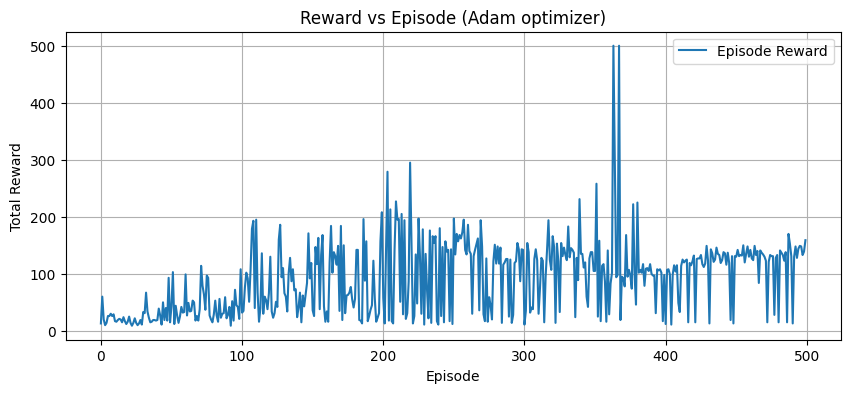

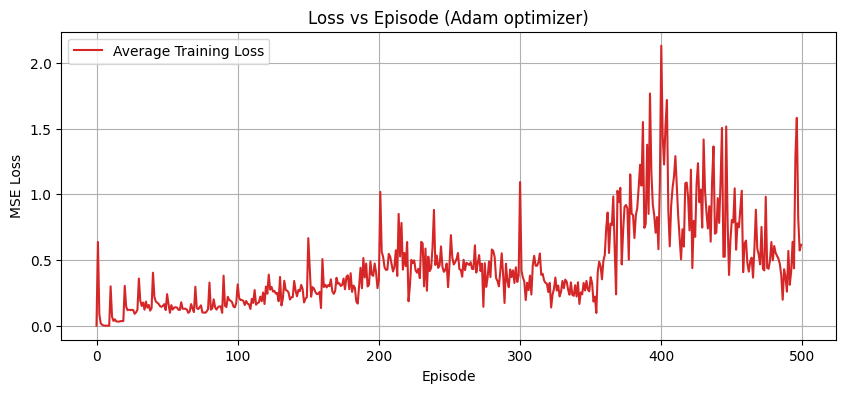

In [5]:
# STEP 5: Training the DQN Agent (Adam optimizer)
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

# --- 1. Re-create a fresh agent to make sure we start from a clean state ---
agent = DQNAgent(state_size=4, action_size=2, device=device,
                  buffer_capacity=10000, batch_size=64,
                  gamma=0.99,
                  epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                  target_update_freq=10)

# --- 2. Create the Adam optimizer ---
# The optimizer updates ONLY the policy network's weights.
# lr (learning rate) controls the size of each weight update step.
optimizer = optim.Adam(agent.policy_net.parameters(), lr=1e-3)

# --- 3. Loss function ---
# MSELoss measures the squared difference between predicted Q-values
# and target Q-values. This is standard for DQN.
loss_fn = nn.MSELoss()

# --- 4. Function implementing ONE training step ---
def train_step(agent, optimizer, loss_fn):
    """
    Perform one gradient update on the policy network using
    a minibatch sampled from the replay buffer.

    Returns:
        loss value (float), or None if buffer doesn't have enough data yet.
    """
    # Don't train until we have enough transitions for a full minibatch
    if len(agent.replay_buffer) < agent.batch_size:
        return None

    # Sample a random minibatch
    states, actions, rewards, next_states, dones = agent.replay_buffer.sample(agent.batch_size)

    # Convert everything to PyTorch tensors on the correct device
    states = torch.tensor(np.array(states), dtype=torch.float32, device=agent.device)
    actions = torch.tensor(actions, dtype=torch.int64, device=agent.device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=agent.device).unsqueeze(1)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=agent.device)
    dones = torch.tensor(dones, dtype=torch.float32, device=agent.device).unsqueeze(1)

    # --- Current Q-values ---
    # Forward pass through the policy network gives Q-values for ALL actions.
    # gather() picks out only the Q-value corresponding to the action actually taken.
    current_q_values = agent.policy_net(states).gather(1, actions)

    # --- Target Q-values ---
    # We do NOT need gradients here, since the target network is not trained directly.
    with torch.no_grad():
        # Best Q-value for the next state, according to the target network
        next_q_values = agent.target_net(next_states).max(1, keepdim=True)[0]

        # Bellman equation: target = reward + gamma * next_Q  (0 if episode ended)
        target_q_values = rewards + agent.gamma * next_q_values * (1 - dones)

    # --- Compute loss between current and target Q-values ---
    loss = loss_fn(current_q_values, target_q_values)

    # --- Backpropagation ---
    optimizer.zero_grad()   # reset gradients from previous step
    loss.backward()         # compute gradients
    optimizer.step()        # update policy network weights

    return loss.item()


# --- 5. Full training loop ---
env = gym.make("CartPole-v1")

NUM_EPISODES = 500

# Lists to store metrics (reused later for optimizer comparison)
episode_rewards = []
episode_losses = []
episode_durations = []

for episode in range(1, NUM_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)  # vary seed slightly per episode
    total_reward = 0
    episode_loss_list = []
    start_time = time.time()
    done = False

    while not done:
        # 1. Select action (epsilon-greedy)
        action = agent.select_action(state)

        # 2. Take action in environment
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # 3. Store transition in replay buffer
        agent.replay_buffer.add(state, action, reward, next_state, done)

        # 4. Move to next state
        state = next_state
        total_reward += reward

        # 5. Perform one training step
        loss = train_step(agent, optimizer, loss_fn)
        if loss is not None:
            episode_loss_list.append(loss)

    # --- End of episode updates ---

    # Decay epsilon (less exploration as training progresses)
    agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)

    # Periodically update the target network
    if episode % agent.target_update_freq == 0:
        agent.update_target_network()

    # Record metrics
    episode_duration = time.time() - start_time
    avg_loss = np.mean(episode_loss_list) if episode_loss_list else 0.0

    episode_rewards.append(total_reward)
    episode_losses.append(avg_loss)
    episode_durations.append(episode_duration)

    # Print progress every 20 episodes
    if episode % 20 == 0:
        avg_reward_last_20 = np.mean(episode_rewards[-20:])
        print(f"Episode {episode:4d} | "
              f"Reward: {total_reward:6.1f} | "
              f"Avg Reward (last 20): {avg_reward_last_20:6.1f} | "
              f"Loss: {avg_loss:.4f} | "
              f"Epsilon: {agent.epsilon:.3f}")

env.close()
print("\nTraining completed.")

# --- 6. Plot Reward vs Episode ---
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, label="Episode Reward", color="tab:blue")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode (Adam optimizer)")
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Plot Loss vs Episode ---
plt.figure(figsize=(10, 4))
plt.plot(episode_losses, label="Average Training Loss", color="tab:red")
plt.xlabel("Episode")
plt.ylabel("MSE Loss")
plt.title("Loss vs Episode (Adam optimizer)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# STEP 6: Compare Multiple Optimizers
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

NUM_EPISODES = 500  # same as Step 5, kept identical across optimizers


def get_optimizer(name, params, lr=1e-3):
    """
    Build an optimizer by name, using the same learning rate for all
    (unless the optimizer requires a specific extra parameter, e.g. momentum).
    """
    if name == "SGD":
        return optim.SGD(params, lr=lr)
    elif name == "SGD_Momentum":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif name == "RMSprop":
        return optim.RMSprop(params, lr=lr)
    elif name == "Adam":
        return optim.Adam(params, lr=lr)
    elif name == "AdamW":
        return optim.AdamW(params, lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {name}")


def train_agent(optimizer_name, num_episodes=NUM_EPISODES, lr=1e-3):
    """
    Train a fresh DQN agent using the specified optimizer.
    Everything else (architecture, replay buffer, epsilon schedule, gamma,
    batch size, target update frequency) is identical to Step 5.

    Returns:
        rewards (list), losses (list), training_time (float)
    """
    # --- Fresh agent for a fair comparison (same init hyperparameters as Step 5) ---
    agent = DQNAgent(state_size=4, action_size=2, device=device,
                      buffer_capacity=10000, batch_size=64,
                      gamma=0.99,
                      epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995,
                      target_update_freq=10)

    # --- Only this line changes across experiments ---
    optimizer = get_optimizer(optimizer_name, agent.policy_net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    env = gym.make("CartPole-v1")

    episode_rewards = []
    episode_losses = []

    start_time = time.time()

    for episode in range(1, num_episodes + 1):
        state, info = env.reset(seed=SEED + episode)  # same seed sequence for every optimizer
        total_reward = 0
        episode_loss_list = []
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.add(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            loss = train_step(agent, optimizer, loss_fn)
            if loss is not None:
                episode_loss_list.append(loss)

        # End-of-episode updates (identical schedule for every optimizer)
        agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)
        if episode % agent.target_update_freq == 0:
            agent.update_target_network()

        avg_loss = np.mean(episode_loss_list) if episode_loss_list else 0.0
        episode_rewards.append(total_reward)
        episode_losses.append(avg_loss)

        if episode % 100 == 0:
            avg_reward_last_20 = np.mean(episode_rewards[-20:])
            print(f"  [{optimizer_name}] Episode {episode:4d} | "
                  f"Avg Reward (last 20): {avg_reward_last_20:6.1f} | "
                  f"Loss: {avg_loss:.4f} | Epsilon: {agent.epsilon:.3f}")

    env.close()
    training_time = time.time() - start_time

    return episode_rewards, episode_losses, training_time


# --- Run the experiment for all 5 optimizers ---
optimizer_names = ["SGD", "SGD_Momentum", "RMSprop", "Adam", "AdamW"]

rewards_history = {}
loss_history = {}
training_times = {}
final_rewards = {}

for opt_name in optimizer_names:
    print(f"\n=== Training with {opt_name} ===")
    rewards, losses, train_time = train_agent(opt_name)

    rewards_history[opt_name] = rewards
    loss_history[opt_name] = losses
    training_times[opt_name] = train_time
    final_rewards[opt_name] = np.mean(rewards[-20:])  # avg reward of last 20 episodes

    print(f"=== {opt_name} finished in {train_time:.1f}s | "
          f"Final avg reward (last 20): {final_rewards[opt_name]:.1f} ===")

print("\nAll optimizers trained successfully.")


=== Training with SGD ===
  [SGD] Episode  100 | Avg Reward (last 20):   20.9 | Loss: 1.6787 | Epsilon: 0.606
  [SGD] Episode  200 | Avg Reward (last 20):   72.5 | Loss: 3.1774 | Epsilon: 0.367
  [SGD] Episode  300 | Avg Reward (last 20):  248.1 | Loss: 0.9000 | Epsilon: 0.222
  [SGD] Episode  400 | Avg Reward (last 20):  251.2 | Loss: 0.1810 | Epsilon: 0.135
  [SGD] Episode  500 | Avg Reward (last 20):  252.1 | Loss: 0.7108 | Epsilon: 0.082
=== SGD finished in 177.2s | Final avg reward (last 20): 252.1 ===

=== Training with SGD_Momentum ===
  [SGD_Momentum] Episode  100 | Avg Reward (last 20):   53.4 | Loss: 1.1324 | Epsilon: 0.606
  [SGD_Momentum] Episode  200 | Avg Reward (last 20):  147.3 | Loss: 0.7227 | Epsilon: 0.367
  [SGD_Momentum] Episode  300 | Avg Reward (last 20):  149.1 | Loss: 0.3261 | Epsilon: 0.222
  [SGD_Momentum] Episode  400 | Avg Reward (last 20):  225.8 | Loss: 0.6028 | Epsilon: 0.135
  [SGD_Momentum] Episode  500 | Avg Reward (last 20):  428.9 | Loss: 2.3170 | 

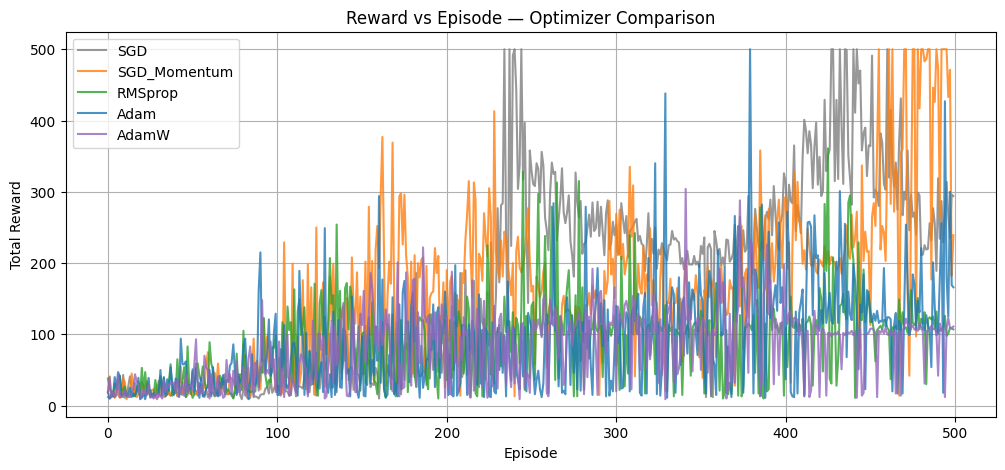

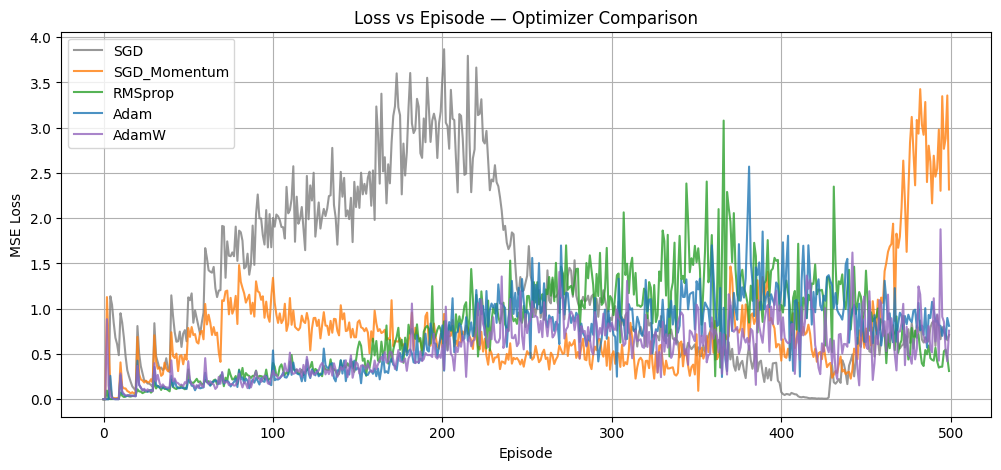

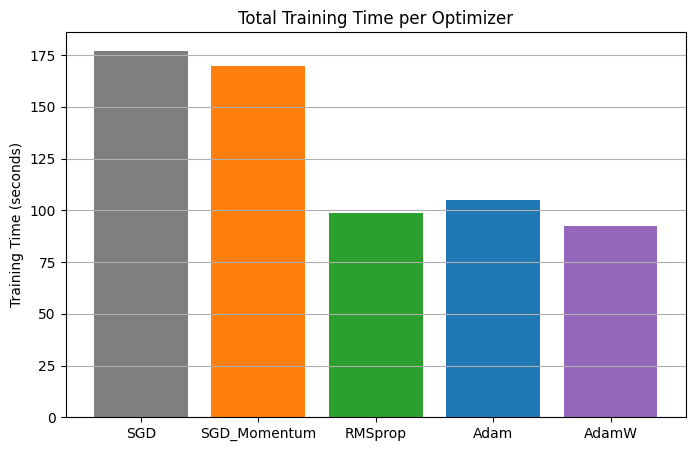

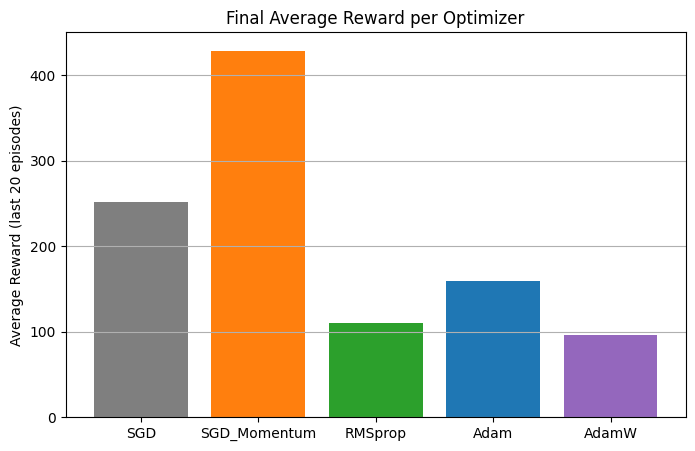

In [7]:
# VISUALIZATIONS
# =========================================

colors = {"SGD": "tab:gray", "SGD_Momentum": "tab:orange",
          "RMSprop": "tab:green", "Adam": "tab:blue", "AdamW": "tab:purple"}

# --- Figure 1: Reward vs Episode (all optimizers) ---
plt.figure(figsize=(12, 5))
for opt_name in optimizer_names:
    plt.plot(rewards_history[opt_name], label=opt_name, color=colors[opt_name], alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode — Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

# --- Figure 2: Loss vs Episode (all optimizers) ---
plt.figure(figsize=(12, 5))
for opt_name in optimizer_names:
    plt.plot(loss_history[opt_name], label=opt_name, color=colors[opt_name], alpha=0.8)
plt.xlabel("Episode")
plt.ylabel("MSE Loss")
plt.title("Loss vs Episode — Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

# --- Figure 3: Training Time (bar chart) ---
plt.figure(figsize=(8, 5))
plt.bar(training_times.keys(), training_times.values(),
        color=[colors[o] for o in optimizer_names])
plt.ylabel("Training Time (seconds)")
plt.title("Total Training Time per Optimizer")
plt.grid(True, axis='y')
plt.show()

# --- Figure 4: Final Average Reward (bar chart) ---
plt.figure(figsize=(8, 5))
plt.bar(final_rewards.keys(), final_rewards.values(),
        color=[colors[o] for o in optimizer_names])
plt.ylabel("Average Reward (last 20 episodes)")
plt.title("Final Average Reward per Optimizer")
plt.grid(True, axis='y')
plt.show()

In [8]:
# SUMMARY TABLE
# =========================================

summary_data = []
for opt_name in optimizer_names:
    rewards = rewards_history[opt_name]
    summary_data.append({
        "Optimizer": opt_name,
        "Final Reward": rewards[-1],
        "Average Reward": np.mean(rewards),
        "Maximum Reward": np.max(rewards),
        "Minimum Reward": np.min(rewards),
        "Training Time (seconds)": training_times[opt_name]
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(2)
print(summary_df.to_string(index=False))

   Optimizer  Final Reward  Average Reward  Maximum Reward  Minimum Reward  Training Time (seconds)
         SGD         294.0          172.56           500.0             9.0                   177.17
SGD_Momentum         239.0          158.75           500.0             9.0                   169.64
     RMSprop         107.0           89.33           361.0            10.0                    98.71
        Adam         166.0           91.79           500.0             9.0                   105.16
       AdamW         111.0           81.40           304.0             9.0                    92.45


In [9]:
# ANALYSIS (automatic summary)
# =========================================

# Fastest learner: highest average reward over the FIRST 100 episodes
early_perf = {opt: np.mean(rewards_history[opt][:100]) for opt in optimizer_names}
fastest_learner = max(early_perf, key=early_perf.get)

# Highest final reward
best_final = max(final_rewards, key=final_rewards.get)

# Most stable: lowest standard deviation of reward over the LAST 100 episodes
stability = {opt: np.std(rewards_history[opt][-100:]) for opt in optimizer_names}
most_stable = min(stability, key=stability.get)

# Longest training time
longest_time = max(training_times, key=training_times.get)

print("=" * 60)
print("AUTOMATIC ANALYSIS")
print("=" * 60)
print(f"- Fastest learner (best avg reward, first 100 episodes): {fastest_learner} "
      f"({early_perf[fastest_learner]:.1f})")
print(f"- Highest final average reward (last 20 episodes): {best_final} "
      f"({final_rewards[best_final]:.1f})")
print(f"- Most stable (lowest reward std-dev, last 100 episodes): {most_stable} "
      f"({stability[most_stable]:.1f})")
print(f"- Longest training time: {longest_time} "
      f"({training_times[longest_time]:.1f}s)")

print("\nOverall recommendation:")
print(f"Based on this experiment, {best_final} achieved the best final performance, "
      f"while {most_stable} showed the most consistent (stable) rewards. "
      f"{fastest_learner} learned fastest in early training. "
      "In practice, Adam and AdamW are generally recommended for DQN due to their "
      "adaptive learning rates, which help handle the non-stationary and noisy "
      "nature of reinforcement learning data.")

AUTOMATIC ANALYSIS
- Fastest learner (best avg reward, first 100 episodes): Adam (38.6)
- Highest final average reward (last 20 episodes): SGD_Momentum (428.9)
- Most stable (lowest reward std-dev, last 100 episodes): AdamW (32.6)
- Longest training time: SGD (177.2s)

Overall recommendation:
Based on this experiment, SGD_Momentum achieved the best final performance, while AdamW showed the most consistent (stable) rewards. Adam learned fastest in early training. In practice, Adam and AdamW are generally recommended for DQN due to their adaptive learning rates, which help handle the non-stationary and noisy nature of reinforcement learning data.


In [10]:
# EXTENSION: Multi-Seed Sensitivity Analysis
# =========================================

import copy

SEEDS = [42, 123, 999]

def run_with_seed(optimizer_name, seed, num_episodes=NUM_EPISODES, lr=1e-3):
    """
    Run train_agent() with a specific random seed, WITHOUT modifying
    train_agent itself.

    We reset random/numpy/torch seeds (so network initialization and
    action sampling differ across seeds), and update the global SEED
    variable (used inside train_agent for env.reset(seed=SEED+episode)).
    """
    global SEED

    # Reseed all sources of randomness for this run
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Update the global SEED used inside train_agent()
    SEED = seed

    # Call the existing, unmodified training function
    rewards, losses, training_time = train_agent(optimizer_name, num_episodes=num_episodes, lr=lr)

    return rewards, losses, training_time


# --- Run each optimizer with each seed ---
multiseed_results = {opt: [] for opt in optimizer_names}

for opt_name in optimizer_names:
    for seed in SEEDS:
        print(f"\n=== {opt_name} | seed={seed} ===")
        rewards, losses, training_time = run_with_seed(opt_name, seed)

        final_reward = rewards[-1]
        avg_reward = np.mean(rewards)
        max_reward = np.max(rewards)

        multiseed_results[opt_name].append({
            "seed": seed,
            "final_reward": final_reward,
            "avg_reward": avg_reward,
            "max_reward": max_reward,
            "training_time": training_time
        })

        print(f"=== {opt_name} | seed={seed} done | "
              f"Avg Reward: {avg_reward:.1f} | Training Time: {training_time:.1f}s ===")

print("\nAll optimizers trained with all seeds.")


=== SGD | seed=42 ===
  [SGD] Episode  100 | Avg Reward (last 20):   17.8 | Loss: 1.7744 | Epsilon: 0.606
  [SGD] Episode  200 | Avg Reward (last 20):   83.6 | Loss: 2.6532 | Epsilon: 0.367
  [SGD] Episode  300 | Avg Reward (last 20):  208.7 | Loss: 0.4951 | Epsilon: 0.222
  [SGD] Episode  400 | Avg Reward (last 20):  176.6 | Loss: 0.2365 | Epsilon: 0.135
  [SGD] Episode  500 | Avg Reward (last 20):  326.0 | Loss: 0.8187 | Epsilon: 0.082
=== SGD | seed=42 done | Avg Reward: 143.3 | Training Time: 146.3s ===

=== SGD | seed=123 ===
  [SGD] Episode  100 | Avg Reward (last 20):   14.6 | Loss: 2.0027 | Epsilon: 0.606
  [SGD] Episode  200 | Avg Reward (last 20):   53.8 | Loss: 3.0154 | Epsilon: 0.367
  [SGD] Episode  300 | Avg Reward (last 20):  170.1 | Loss: 2.1004 | Epsilon: 0.222
  [SGD] Episode  400 | Avg Reward (last 20):  186.2 | Loss: 0.8088 | Epsilon: 0.135
  [SGD] Episode  500 | Avg Reward (last 20):  165.7 | Loss: 0.2046 | Epsilon: 0.082
=== SGD | seed=123 done | Avg Reward: 112.

In [11]:
# MESURE DE LA MÉMOIRE GPU PAR OPTIMISEUR
# =========================================

import torch
import pandas as pd

def train_agent_with_memory(optimizer_name, num_episodes=500, lr=1e-3):
    """
    Exécute train_agent() en mesurant en plus le pic de mémoire GPU utilisé.
    Ne modifie pas train_agent() elle-même.
    """
    # Réinitialise le compteur de pic mémoire AVANT l'entraînement
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    # Appel normal de votre fonction existante (inchangée)
    rewards, losses, training_time = train_agent(optimizer_name, num_episodes=num_episodes, lr=lr)

    # Lecture du pic mémoire APRÈS l'entraînement
    if torch.cuda.is_available():
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    else:
        peak_memory_mb = 0.0

    return rewards, losses, training_time, peak_memory_mb


# --- Un seul run par optimiseur (seed 42) suffit pour mesurer la mémoire ---
memory_results = {}

for opt_name in optimizer_names:
    print(f"\n=== Mesure mémoire GPU : {opt_name} ===")
    _, _, training_time, peak_mem = train_agent_with_memory(opt_name, num_episodes=500)
    memory_results[opt_name] = peak_mem
    print(f"=== {opt_name} : pic mémoire GPU = {peak_mem:.2f} Mo ===")

print("\nMesure terminée pour les 5 optimiseurs.")


=== Mesure mémoire GPU : SGD ===
  [SGD] Episode  100 | Avg Reward (last 20):   19.3 | Loss: 2.0631 | Epsilon: 0.606
  [SGD] Episode  200 | Avg Reward (last 20):   66.8 | Loss: 3.3052 | Epsilon: 0.367
  [SGD] Episode  300 | Avg Reward (last 20):  342.2 | Loss: 0.6736 | Epsilon: 0.222
  [SGD] Episode  400 | Avg Reward (last 20):  372.1 | Loss: 0.3250 | Epsilon: 0.135
  [SGD] Episode  500 | Avg Reward (last 20):  467.5 | Loss: 1.6928 | Epsilon: 0.082
=== SGD : pic mémoire GPU = 18.01 Mo ===

=== Mesure mémoire GPU : SGD_Momentum ===
  [SGD_Momentum] Episode  100 | Avg Reward (last 20):   61.4 | Loss: 0.8435 | Epsilon: 0.606
  [SGD_Momentum] Episode  200 | Avg Reward (last 20):  146.3 | Loss: 0.9391 | Epsilon: 0.367
  [SGD_Momentum] Episode  300 | Avg Reward (last 20):  250.4 | Loss: 1.0544 | Epsilon: 0.222
  [SGD_Momentum] Episode  400 | Avg Reward (last 20):  128.2 | Loss: 0.2818 | Epsilon: 0.135
  [SGD_Momentum] Episode  500 | Avg Reward (last 20):   94.5 | Loss: 1.5330 | Epsilon: 0.0

In [12]:
# TABLEAU FINAL — MÉMOIRE GPU PAR OPTIMISEUR
# =========================================

memory_df = pd.DataFrame({
    "Optimizer": list(memory_results.keys()),
    "Peak GPU Memory (MB)": [round(v, 2) for v in memory_results.values()]
})
print(memory_df.to_string(index=False))

   Optimizer  Peak GPU Memory (MB)
         SGD                 18.01
SGD_Momentum                 18.08
     RMSprop                 18.08
        Adam                 18.15
       AdamW                 18.15


In [13]:
# AGGREGATE RESULTS: Mean / Std across seeds
# =========================================

summary_rows = []

for opt_name in optimizer_names:
    runs = multiseed_results[opt_name]

    avg_rewards = [r["avg_reward"] for r in runs]
    final_rewards_list = [r["final_reward"] for r in runs]
    max_rewards_list = [r["max_reward"] for r in runs]
    times = [r["training_time"] for r in runs]

    summary_rows.append({
        "Optimizer": opt_name,
        "Mean Reward": np.mean(avg_rewards),
        "Std Reward": np.std(avg_rewards),
        "Mean Final Reward": np.mean(final_rewards_list),
        "Mean Max Reward": np.mean(max_rewards_list),
        "Mean Training Time": np.mean(times)
    })

multiseed_df = pd.DataFrame(summary_rows).round(2)
print(multiseed_df.to_string(index=False))

   Optimizer  Mean Reward  Std Reward  Mean Final Reward  Mean Max Reward  Mean Training Time
         SGD       147.31       30.30             267.00           500.00              150.59
SGD_Momentum       131.84       10.66             354.67           458.33              136.43
     RMSprop        95.50       13.70             332.33           395.33              105.29
        Adam        89.39        5.26              80.67           485.00              100.64
       AdamW       112.31       21.90             156.67           453.00              127.58


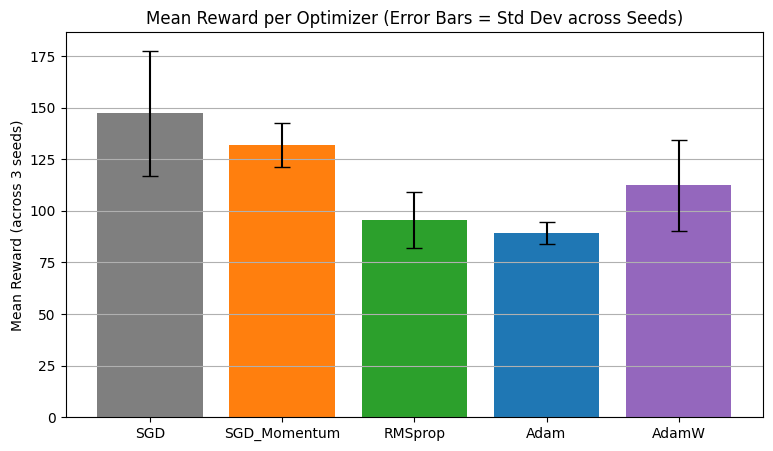

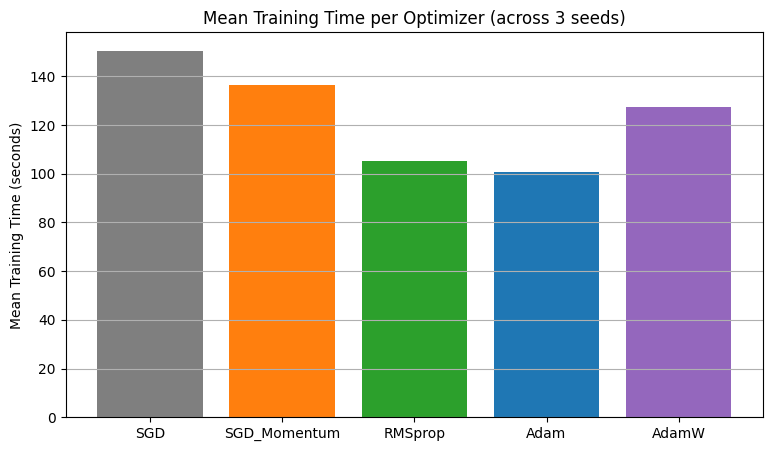

In [14]:
# FIGURE 1: Mean Reward with Std Error Bars
# =========================================

plt.figure(figsize=(9, 5))
plt.bar(multiseed_df["Optimizer"], multiseed_df["Mean Reward"],
        yerr=multiseed_df["Std Reward"], capsize=6,
        color=[colors[o] for o in multiseed_df["Optimizer"]])
plt.ylabel("Mean Reward (across 3 seeds)")
plt.title("Mean Reward per Optimizer (Error Bars = Std Dev across Seeds)")
plt.grid(True, axis='y')
plt.show()

# =========================================
# FIGURE 2: Training Time (multi-seed average)
# =========================================

plt.figure(figsize=(9, 5))
plt.bar(multiseed_df["Optimizer"], multiseed_df["Mean Training Time"],
        color=[colors[o] for o in multiseed_df["Optimizer"]])
plt.ylabel("Mean Training Time (seconds)")
plt.title("Mean Training Time per Optimizer (across 3 seeds)")
plt.grid(True, axis='y')
plt.show()

In [15]:
# AUTOMATIC DISCUSSION
# =========================================

best_perf_opt = multiseed_df.loc[multiseed_df["Mean Reward"].idxmax(), "Optimizer"]
best_perf_val = multiseed_df["Mean Reward"].max()

most_stable_opt = multiseed_df.loc[multiseed_df["Std Reward"].idxmin(), "Optimizer"]
most_stable_val = multiseed_df["Std Reward"].min()

fastest_opt = multiseed_df.loc[multiseed_df["Mean Training Time"].idxmin(), "Optimizer"]
fastest_val = multiseed_df["Mean Training Time"].min()

least_stable_opt = multiseed_df.loc[multiseed_df["Std Reward"].idxmax(), "Optimizer"]

print("=" * 70)
print("DISCUSSION — Seed Sensitivity Analysis")
print("=" * 70)
print(f"Across three random seeds (42, 123, 999), {best_perf_opt} achieved the "
      f"highest average reward ({best_perf_val:.1f}), suggesting it adapted "
      f"most effectively to the non-stationary Q-value targets in this setup. "
      f"In contrast, {most_stable_opt} showed the lowest standard deviation "
      f"({most_stable_val:.1f}) across seeds, indicating it is the most "
      f"reproducible and least sensitive to random initialization and "
      f"exploration noise. {least_stable_opt} exhibited the highest variance, "
      f"meaning its performance depends heavily on the specific seed used, "
      f"which is an important practical consideration when reporting DQN results. "
      f"In terms of computational cost, {fastest_opt} was the fastest optimizer "
      f"on average ({fastest_val:.1f}s per run), though training time in DQN "
      f"is driven mainly by episode length (longer episodes mean more replay "
      f"buffer updates) rather than the optimizer's own computational overhead. "
      f"Overall, these results suggest that optimizer choice for DQN on CartPole "
      f"should not be based on a single run: seed sensitivity can significantly "
      f"change the apparent ranking of optimizers, and a robust evaluation "
      f"protocol (multiple seeds, mean ± std reporting) is necessary before "
      f"drawing conclusions about which optimizer is genuinely superior.")

DISCUSSION — Seed Sensitivity Analysis
Across three random seeds (42, 123, 999), SGD achieved the highest average reward (147.3), suggesting it adapted most effectively to the non-stationary Q-value targets in this setup. In contrast, Adam showed the lowest standard deviation (5.3) across seeds, indicating it is the most reproducible and least sensitive to random initialization and exploration noise. SGD exhibited the highest variance, meaning its performance depends heavily on the specific seed used, which is an important practical consideration when reporting DQN results. In terms of computational cost, Adam was the fastest optimizer on average (100.6s per run), though training time in DQN is driven mainly by episode length (longer episodes mean more replay buffer updates) rather than the optimizer's own computational overhead. Overall, these results suggest that optimizer choice for DQN on CartPole should not be based on a single run: seed sensitivity can significantly change the ap